<a href="https://colab.research.google.com/github/Shaheen614/Summer-of-ML/blob/main/W1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-1 Assignment

# **Gotta catch 'em all !**

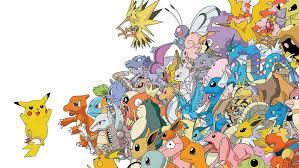

**Welcome to your first graded assignment! Hope that you are excited to implement and test everything you have learnt up until now. The dataset which you'll use includes information about Pokemons.**

**We have got an interesting set of questions for you to get a basic understanding of pandas and data visualization libraries. GOOD LUCK!**


***Let's get started with importing numpy, pandas, seaborn and matplotlib!***

Note - matplotlib should be imported with the command :

 `import matplotlib.pyplot as plt`

### 1) Start by importing all important libraries
For eg, "import numpy as np"

In [1]:
import pandas as pd
import numpy as np

### 2) Read the csv file and assign it to a variable .

In [2]:
df = pd.read_csv('W1_Pokemon.csv')

### 3) Display shape of dataframe
Expected Output - (800, 13)

In [3]:
print(df.shape)

(800, 13)


### 4) Print all columns of dataframe
Return an array containing names of all the columns.

In [4]:
print(df.columns)

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')


### 5) Remove the column '#' and update the dataframe.

In [5]:
df = df.drop(columns='#')

### 6) Set the 'Name' column as the index of dataframe

In [6]:
df = df.set_index('Name')

###  7) Print a list of all the unique Type-1 powers

In [7]:
print(df['Type 1'].unique())

<StringArray>
[   'Grass',     'Fire',    'Water',      'Bug',   'Normal',   'Poison',
 'Electric',   'Ground',    'Fairy', 'Fighting',  'Psychic',     'Rock',
    'Ghost',      'Ice',   'Dragon',     'Dark',    'Steel',   'Flying']
Length: 18, dtype: str


### 8) Create a column which contains the Type 1 and Type 2 abilities of pokemons, seperated with a '+'' sign. Also, display the no. of pokemons that have type-1 power as 'Psychic' and type 2 power as 'Flying' using this new column.

In [20]:
df['Types'] = df['Type 1'] + '+' + df['Type 2']
print(df[(df['Types']=='Psychic+Flying')].shape[0])

6


## GRADED Questions (To be answered in the quiz)
### Try to retrieve some information from the data and answer the questions below . BEST OF LUCK !!

### 1. How many pokemons have 'Mega' in their name?

In [26]:
import pandas as pd
df = pd.read_csv('W1_Pokemon.csv')

print(df['Name'].str.contains("Mega").sum())

49


### 2. What is the standard deviation of Sp. Def. in the dataset ?

In [31]:
import pandas as pd
df = pd.read_csv('W1_Pokemon.csv')

std = df['Sp. Def'].std()

print(f"{std:.2f}")

27.83


### 3. What percentage (upto 3 decimal places) of pokemons are legendary ?

In [32]:
import pandas as pd

df = pd.read_csv('W1_Pokemon.csv')

percentage = df["Legendary"].mean()*100

print(f"{percentage:.3f}%")

8.125%


### 4. Name the pokemon(s) with Maximum Defense.

In [33]:
import pandas as pd
df = pd.read_csv('W1_Pokemon.csv')

print(df[(df["Defense"]==df["Defense"].max())]["Name"])

224    SteelixMega Steelix
230                Shuckle
333      AggronMega Aggron
Name: Name, dtype: str


### 5. Which poison pokemon has the strongest attack ?

In [42]:
import pandas as pd

df = pd.read_csv('W1_Pokemon.csv')

poison_type = df[(df["Type 1"]=="Poison")|(df["Type 2"]=="Poison")]

strongest_poison = poison_type.loc[poison_type["Attack"].idxmax(), "Name"]
print(strongest_poison)

BeedrillMega Beedrill


### 6. Using seaborn make different types of plots, observe the trend and answer the questions given in the form.

/tmp/ipykernel_536077/600989839.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=type_totals, x='Type 1', y='Total', palette='Set2')


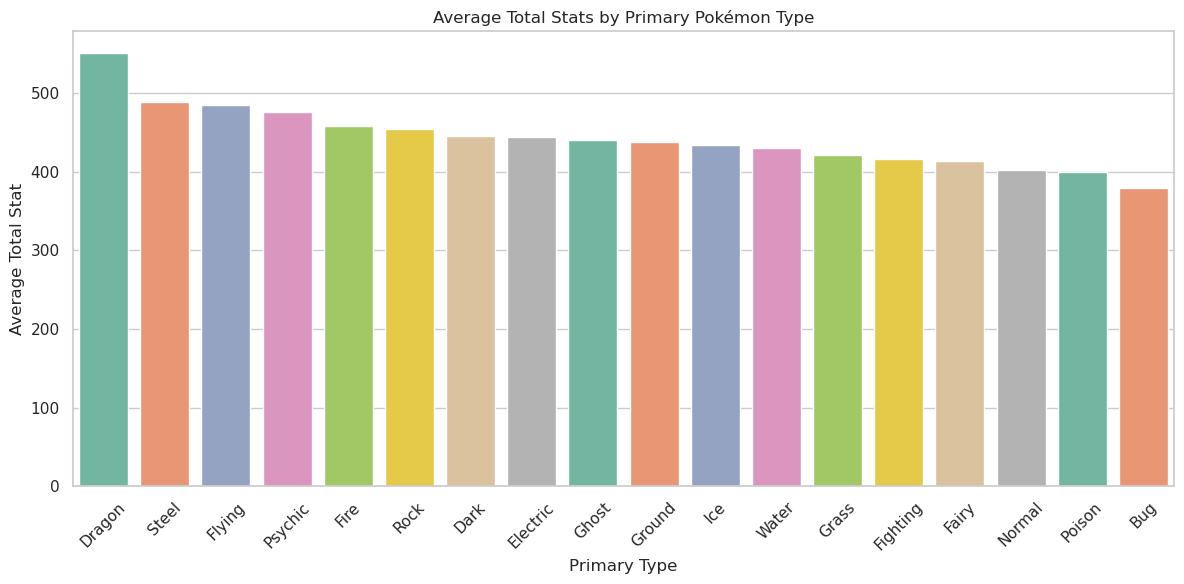

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('W1_Pokemon.csv')


type_totals = df.groupby('Type 1')['Total'].mean().reset_index()


type_totals = type_totals.sort_values('Total', ascending=False)


sns.set(style="whitegrid")


plt.figure(figsize=(12, 6))
ax = sns.barplot(data=type_totals, x='Type 1', y='Total', palette='Set2')


plt.title('Average Total Stats by Primary Pokémon Type')
plt.xlabel('Primary Type')
plt.ylabel('Average Total Stat')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


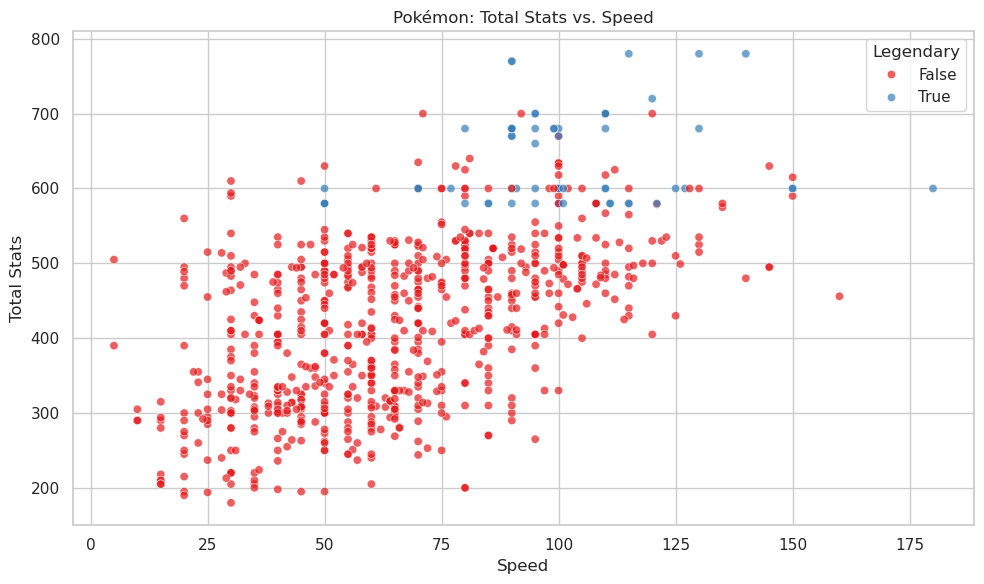

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('W1_Pokemon.csv')


sns.set(style="whitegrid")


plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=df,
    x='Speed',
    y='Total',
    hue='Legendary',
    palette='Set1',
    alpha=0.7
)


plt.title('Pokémon: Total Stats vs. Speed')
plt.xlabel('Speed')
plt.ylabel('Total Stats')
plt.legend(title='Legendary')
plt.tight_layout()
plt.show()



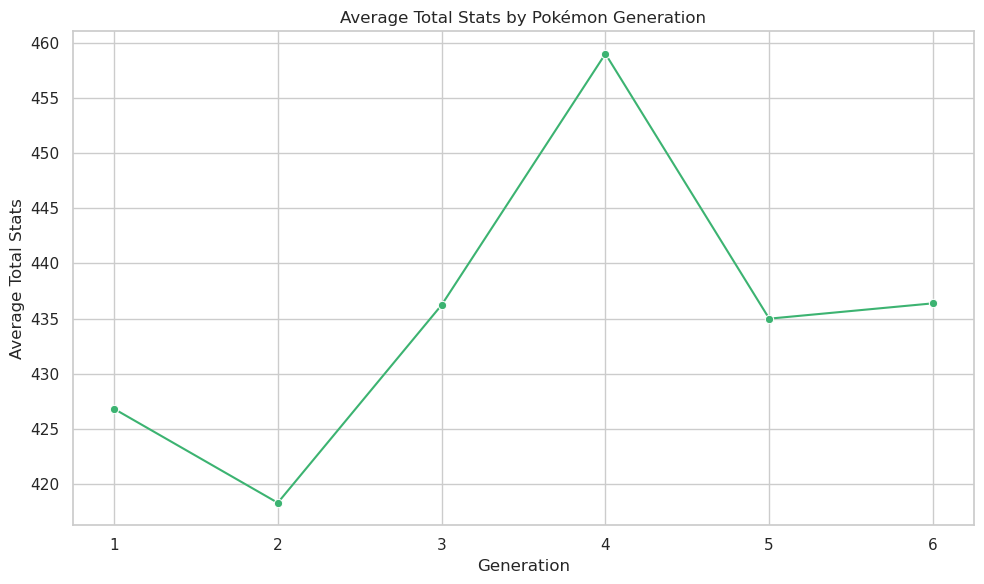

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('W1_Pokemon.csv')
df = df.set_index('Name')
# Calculate Generation-wise average for Total stats
gen_avg = df.groupby('Generation')['Total'].mean().reset_index()


sns.set(style="whitegrid")


plt.figure(figsize=(10, 6))
sns.lineplot(data=gen_avg, x='Generation', y='Total', marker='o', color='mediumseagreen')

plt.title('Average Total Stats by Pokémon Generation')
plt.xlabel('Generation')
plt.ylabel('Average Total Stats')
plt.xticks(gen_avg['Generation'])
plt.tight_layout()
plt.show()


### 7. Which is the second fastest non-legendary 'Ghost' type pokemon from 4th generation ?

In [36]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")

g4 = df["Generation"]==4
ghost = (df['Type 1']=='Ghost')|(df['Type 2']=='Ghost')
non_leg = df["Legendary"]==False

required = df[g4 & ghost & non_leg]

required = required.iloc[1]['Name']
print(second_fastest)

Mismagius


### 8. How many non-legendary pokemons have stronger defence but weaker attack than Charizard?

In [37]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")

df = df.set_index('Name')
char_def = df.loc['Charizard']['Defense']
char_att = df.loc['Charizard']['Attack']

strong_def = df['Defense'] > char_def
weak_att = df['Attack'] < char_att
non_leg = df["Legendary"] == False

count = df[strong_def & weak_att & non_leg].shape[0]
print(count)


116



## ***Bonus Questions***
## Here are some bonus questions that you can try further !

### These questions are UNGRADED, and are given as an extra exercise.

### Which pokemon has the highest combined value of Attack and Sp. Atk ?

In [63]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")
combined = df['Attack'] + df['Sp. Atk']

req_pokemon = df.iloc[combined.idxmax()]['Name']
print(req_pokemon)

RayquazaMega Rayquaza


### Which type of legendary pokemons are the most common?

In [64]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")
leg = df[df["Legendary"]==True]
types = pd.concat([leg['Type 1'], leg['Type 2']])
counts = types.value_counts()

print(counts.idxmax())

Psychic


### How many generation-3, non-legendary pokemons have higher HP than the weakest generation-6, legendary pokemon?

In [104]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")

df = df.set_index('Name')

non_leg = df['Legendary']==False
gen3 = df['Generation']==3
gen6 = df['Generation']==6

weakest = df[(~non_leg) & gen6]['HP'].min()

non_leg_gen3 = df[non_leg & gen3]

counts = len(non_leg_gen3[(non_leg_gen3['HP'] > weakest)])
print(counts)

95


### Print out the third slowest pokemon(s) in the dataset.

In [115]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")

df = df.set_index('Name')

last3 = df.nsmallest(3, 'Speed')
req_pokemon = last3.iloc[-1].name
print(req_pokemon)

Trapinch


### Which pokemon type has the highest average HP?

In [124]:
import pandas as pd

df = pd.read_csv("W1_Pokemon.csv")

df = df.set_index('Name')

avg_hp = df.groupby('Type 1')['HP'].mean()
print(avg_hp.idxmax())


Dragon
